# Medical Cost Prediction Using Linear Regression

This project explores the factors associated with individual medical insurance charges and builds a machine learning model to predict medical costs.

The project follows a complete machine learning workflow:

1. Data loading and inspection
2. Exploratory Data Analysis (EDA)
3. Feature analysis and visualization
4. Data preprocessing
5. Understanding linear regression from scratch
6. Building a Linear Regression model
7. Encoding categorical variables
8. Feature scaling
9. Train/test split
10. Model evaluation
11. Feature interpretation
12. Final conclusions

The main objective is to understand how demographic and lifestyle-related features can be used to predict medical charges.

## Dataset

The dataset contains information about individuals and their medical insurance charges.

### Features

- `age` — age of the individual
- `sex` — biological sex
- `bmi` — body mass index
- `children` — number of children/dependents
- `smoker` — whether the individual is a smoker
- `region` — residential region
- `charges` — individual medical insurance charges

### Target

The target variable is:

`charges`

This is a **regression problem** because the target is a continuous numerical value.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## 1. Loading the Data

The dataset is loaded from a CSV file.

For a GitHub repository, the recommended structure is:

```text
medical-cost-prediction/
│
├── Medical_Charges.ipynb
├── medical-charges.csv
├── README.md
└── requirements.txt

In [5]:
df = pd.read_csv("medical-charges.csv")

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The dataset contains 1,338 observations and 7 columns.

The first few rows show that the dataset contains both numerical and categorical variables, so preprocessing will be required before training a regression model.

In [7]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (1338, 7)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Initial observations

From the descriptive statistics:

- Age ranges from 18 to 64.
- BMI ranges from approximately 16 to 53.
- The number of children ranges from 0 to 5.
- Medical charges vary substantially, indicating that the target may be influenced strongly by some categorical or lifestyle variables.

Before modeling, we will investigate these relationships visually.

# 2. Exploratory Data Analysis

Exploratory Data Analysis helps us understand the structure of the dataset and identify potentially important relationships between the features and medical charges.

We will examine:

- Age distribution
- BMI distribution
- Medical charge distribution
- Smoking status
- Age vs. medical charges
- BMI vs. medical charges
- Differences between smokers and non-smokers
- Regional differences
- Number of children
- Correlations between numerical variables

In [10]:
df["age"].describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


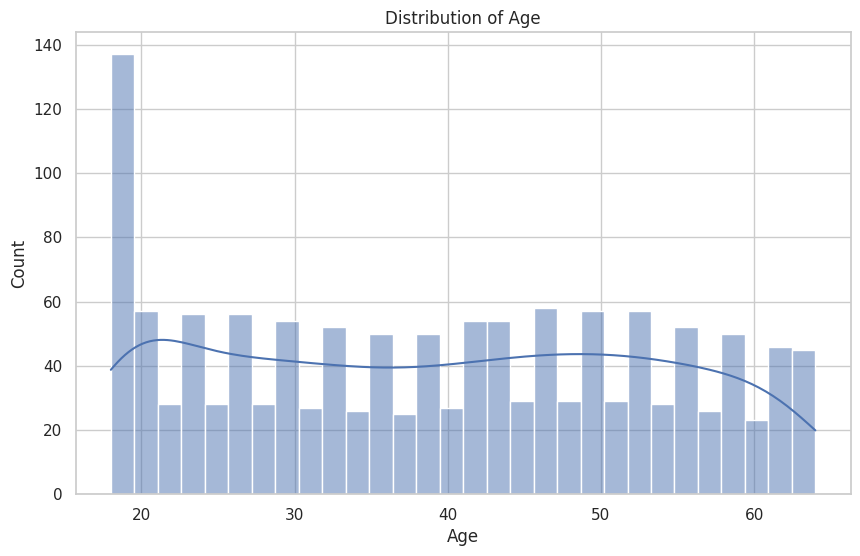

In [11]:
sns.histplot(data=df, x="age", bins=30, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

The age distribution covers adults from 18 to 64 years old.

The distribution appears reasonably spread across the available age range, allowing us to investigate age as a potential predictor of medical charges.

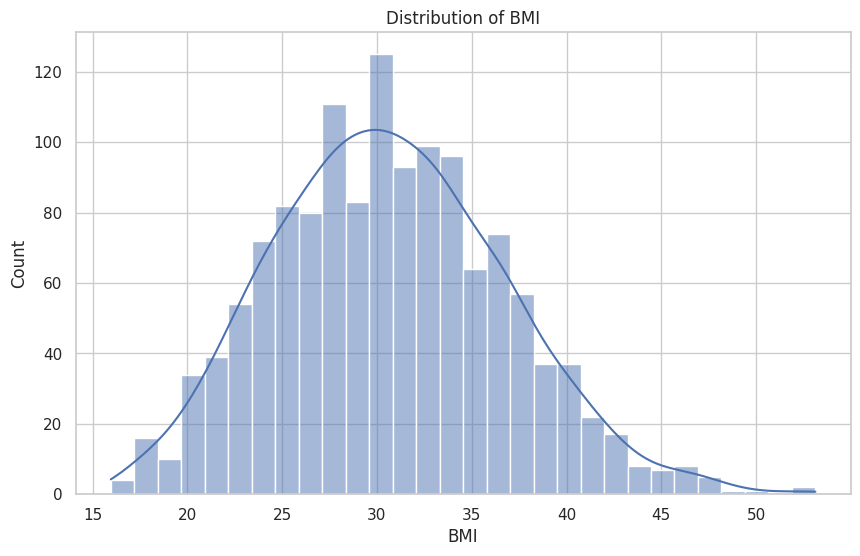

In [12]:
sns.histplot(data=df, x="bmi", bins=30, kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

BMI is distributed across a relatively wide range.

We will later investigate whether BMI has a meaningful relationship with medical charges and whether this relationship differs depending on smoking status.

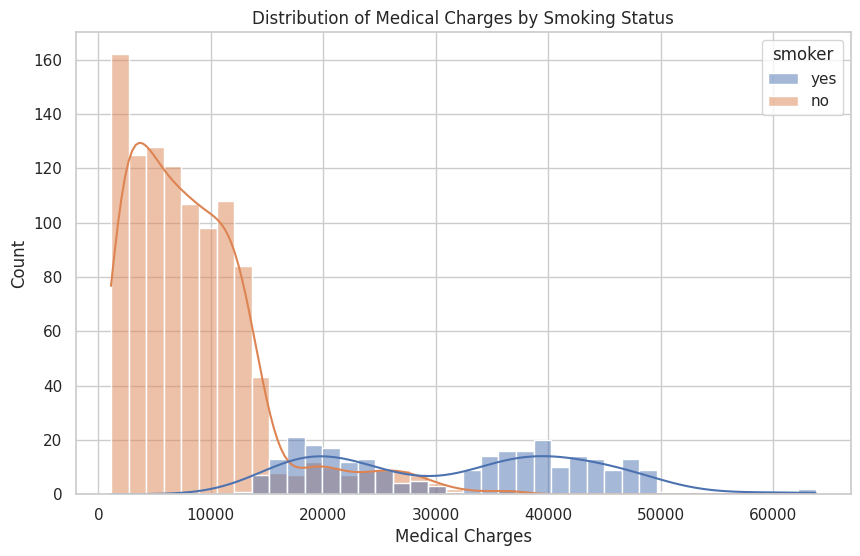

In [13]:
sns.histplot(
    data=df,
    x="charges",
    hue="smoker",
    bins=40,
    kde=True
)

plt.title("Distribution of Medical Charges by Smoking Status")
plt.xlabel("Medical Charges")
plt.ylabel("Count")
plt.show()

The distribution of medical charges differs substantially between smokers and non-smokers.

This suggests that `smoker` may be one of the most important features for predicting medical charges.

In [14]:
df["smoker"].value_counts()

,count
smoker,
no,1064
yes,274


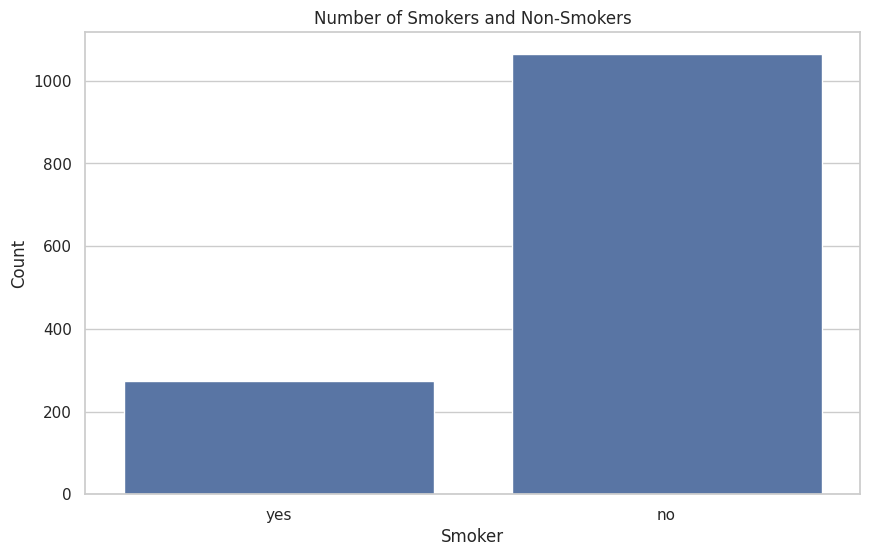

In [15]:
sns.countplot(data=df, x="smoker")

plt.title("Number of Smokers and Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.show()

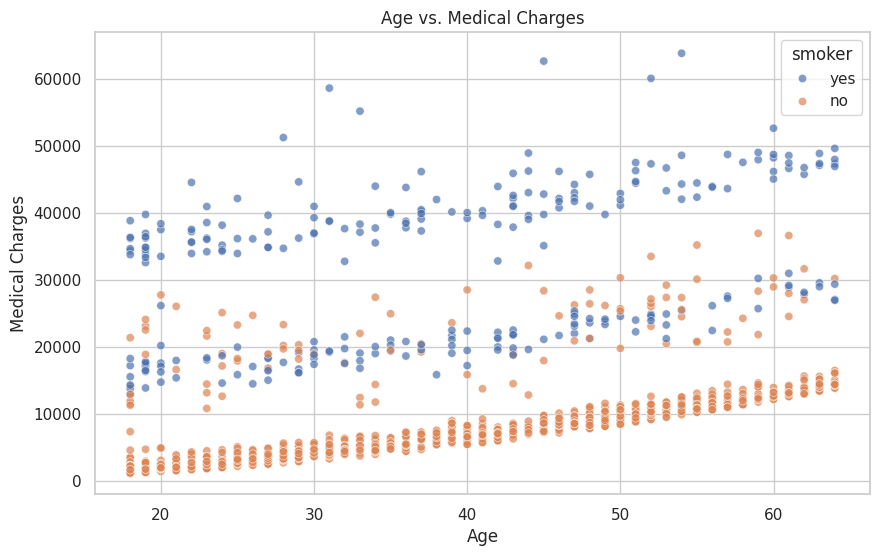

In [16]:
sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker",
    alpha=0.7
)

plt.title("Age vs. Medical Charges")
plt.xlabel("Age")
plt.ylabel("Medical Charges")
plt.show()

There appears to be a positive relationship between age and medical charges.

However, the plot also shows a much larger separation between smokers and non-smokers than age alone can explain.

This suggests that a useful model should include both numerical features such as age and categorical features such as smoking status.

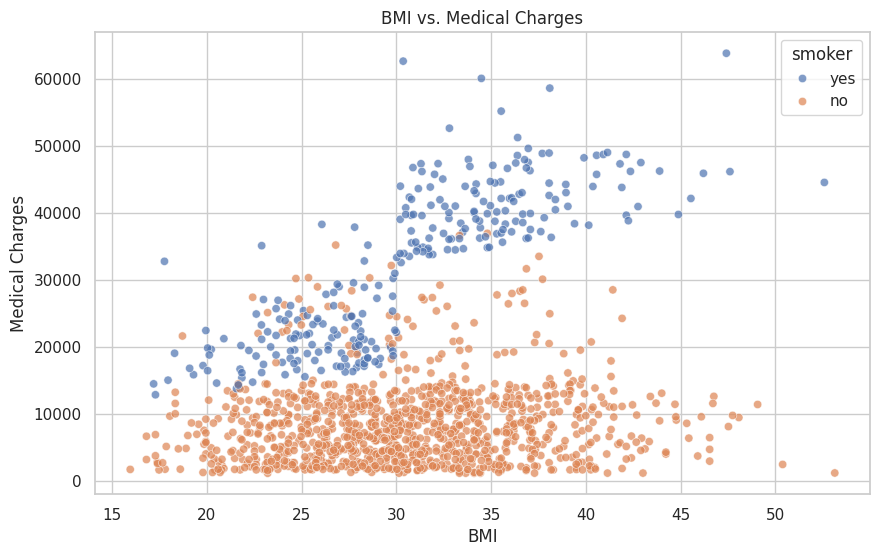

In [17]:
sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker",
    alpha=0.7
)

plt.title("BMI vs. Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Medical Charges")
plt.show()

BMI shows a weaker overall relationship with medical charges than smoking status.

However, the relationship becomes more interesting when smokers and non-smokers are considered separately. This suggests that interactions between features may be important, although this project focuses on standard linear regression.

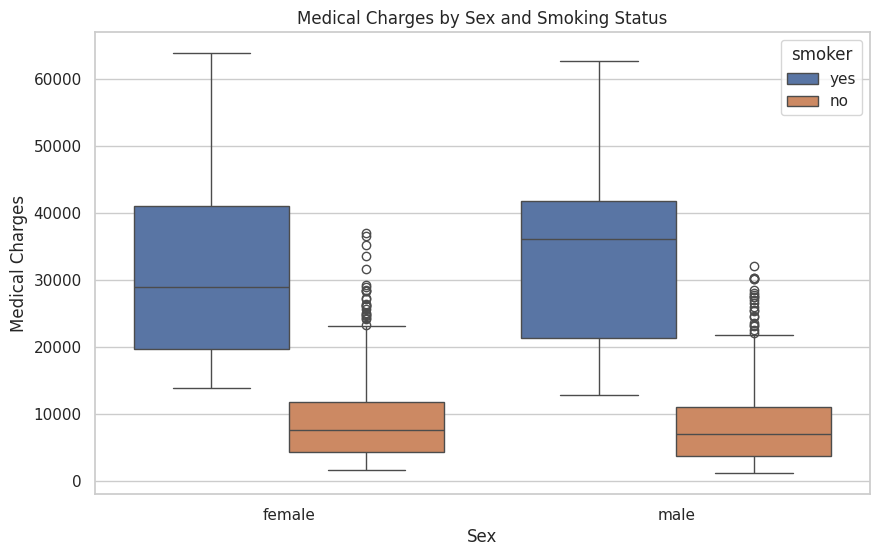

In [18]:
sns.boxplot(
    data=df,
    x="sex",
    y="charges",
    hue="smoker"
)

plt.title("Medical Charges by Sex and Smoking Status")
plt.xlabel("Sex")
plt.ylabel("Medical Charges")
plt.show()

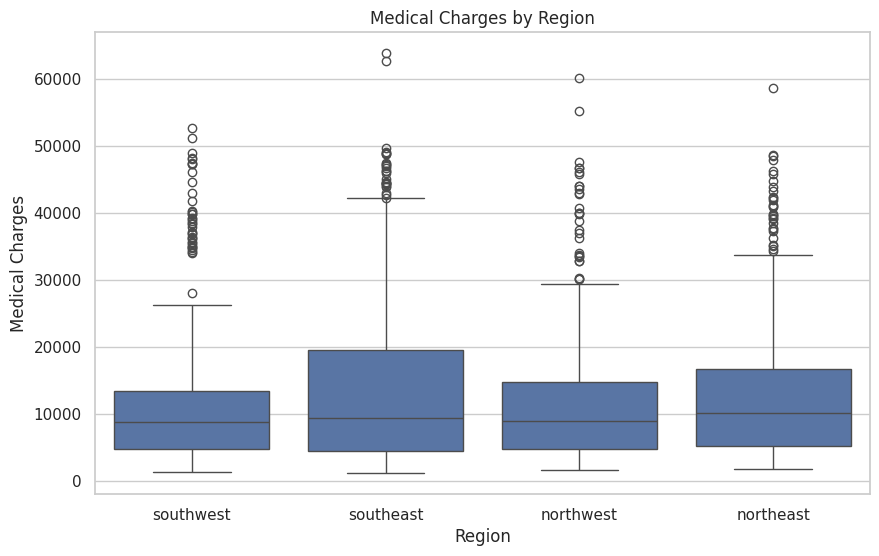

In [19]:
sns.boxplot(
    data=df,
    x="region",
    y="charges"
)

plt.title("Medical Charges by Region")
plt.xlabel("Region")
plt.ylabel("Medical Charges")
plt.show()

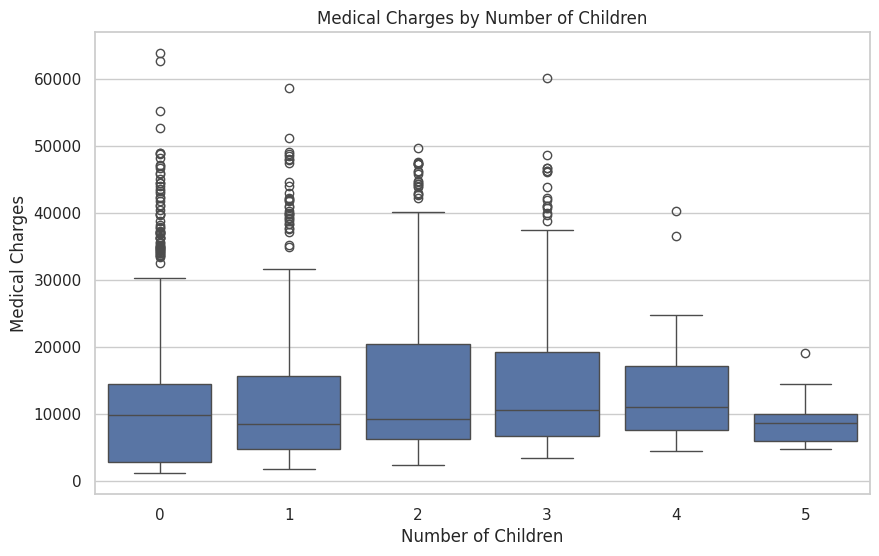

In [20]:
sns.boxplot(
    data=df,
    x="children",
    y="charges"
)

plt.title("Medical Charges by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Medical Charges")
plt.show()

In [21]:
df["children"].value_counts().sort_index()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


### Correlation Analysis

Correlation measures the linear relationship between numerical variables.

A value close to:

- `+1` indicates a strong positive relationship
- `0` indicates little or no linear relationship
- `-1` indicates a strong negative relationship

Correlation does not imply causation, but it can help identify potentially useful predictors.

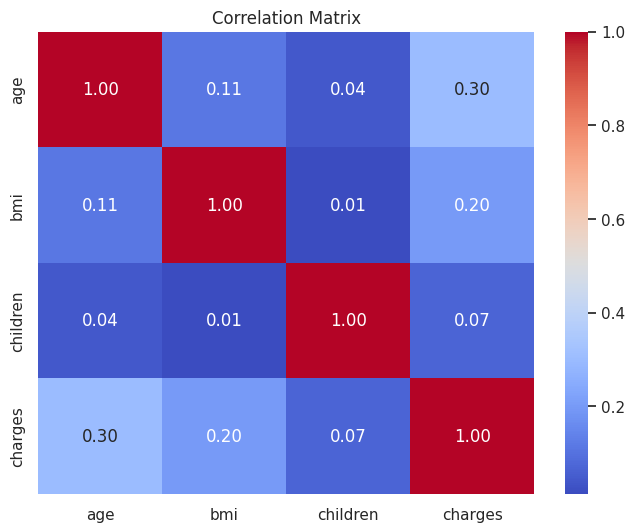

In [22]:
numeric_columns = df.select_dtypes(include="number").columns

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [23]:
df["charges"].corr(df["age"])

np.float64(0.2990081933306476)

The correlation between age and medical charges is positive, supporting the visual observation that older individuals tend to have higher charges.

However, correlation alone is not enough to build a good predictive model. We need to consider categorical variables and evaluate the model on unseen data.

# 3. Understanding Linear Regression

Before building the final model, it is useful to understand the basic idea behind linear regression.

For a single feature, linear regression can be written as:

\[
\hat{y} = wx + b
\]

where:

- `x` is the input feature
- `w` is the weight/coefficient
- `b` is the intercept
- `ŷ` is the predicted value

The goal is to find values of `w` and `b` that make predictions as close as possible to the actual target values.

### Simple Linear Model

To make the concept easier to visualize, we will initially work only with non-smokers and use age as the predictor.

This is not our final model. It is simply an educational step to understand how a linear model behaves.

In [24]:
non_smoker_df = df[df["smoker"] == "no"].copy()

non_smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [25]:
def estimate_charges(age, weight, bias):
    return age * weight + bias

In [26]:
estimate_charges(30, 50, 100)

1600

The function implements:

\[
y' = wx + b
\]

For example, with:

- `w = 50`
- `b = 100`
- `x = 30`

the predicted charge is:

\[
50(30) + 100 = 1600
\]

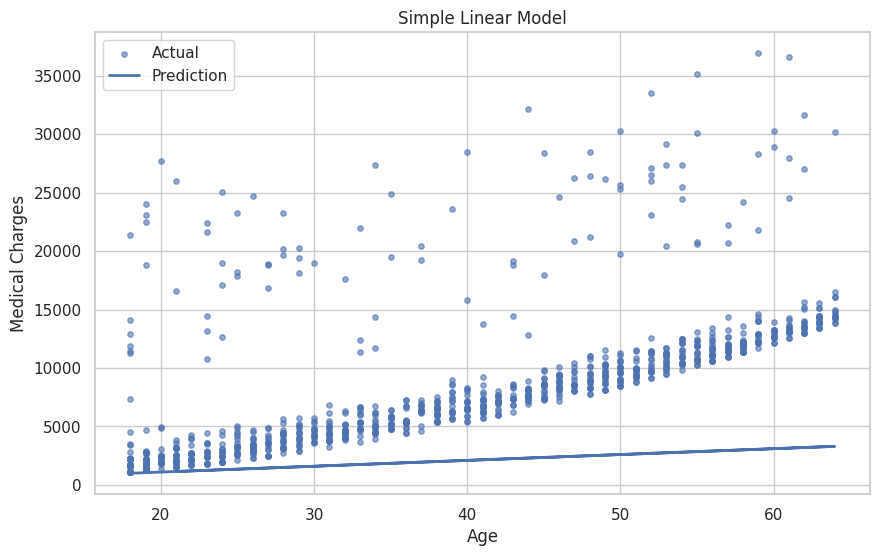

In [27]:
ages = non_smoker_df["age"]
target = non_smoker_df["charges"]

weight = 50
bias = 100

estimated_charges = estimate_charges(ages, weight, bias)

plt.scatter(ages, target, s=15, alpha=0.6, label="Actual")
plt.plot(ages, estimated_charges, linewidth=2, label="Prediction")

plt.title("Simple Linear Model")
plt.xlabel("Age")
plt.ylabel("Medical Charges")
plt.legend()
plt.show()

The line represents the predictions produced by the chosen weight and bias.

Changing `w` changes the slope of the line, while changing `b` shifts the line vertically.

A good linear regression model should choose parameters that minimize prediction error.

In [28]:
def rmse(targets, predictions):
    return np.sqrt(np.mean((targets - predictions) ** 2))

### Root Mean Squared Error

RMSE measures the average size of prediction errors while giving larger errors more influence.

\[
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
\]

A lower RMSE indicates that predictions are, on average, closer to the actual values.

The units of RMSE are the same as the target variable, which makes it relatively easy to interpret.

In [29]:
def evaluate_parameters(weight, bias):
    predictions = estimate_charges(ages, weight, bias)
    loss = rmse(target, predictions)

    print(f"Weight: {weight}")
    print(f"Bias: {bias}")
    print(f"RMSE: {loss:.2f}")

    plt.scatter(ages, target, s=15, alpha=0.6, label="Actual")
    plt.plot(ages, predictions, linewidth=2, label="Prediction")

    plt.title(f"Linear Model: w={weight}, b={bias}")
    plt.xlabel("Age")
    plt.ylabel("Medical Charges")
    plt.legend()
    plt.show()

Weight: 60
Bias: 200
RMSE: 8044.91


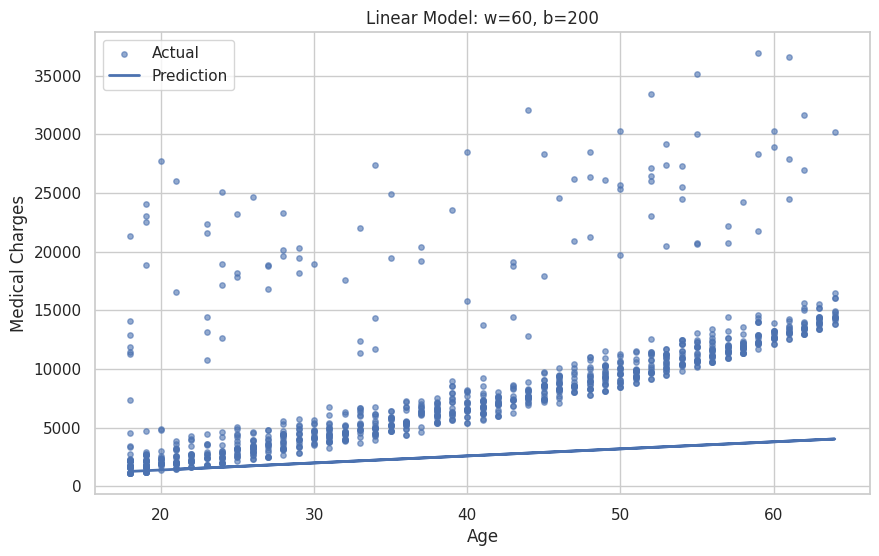

In [30]:
evaluate_parameters(60, 200)

Weight: 270
Bias: -3000
RMSE: 4730.84


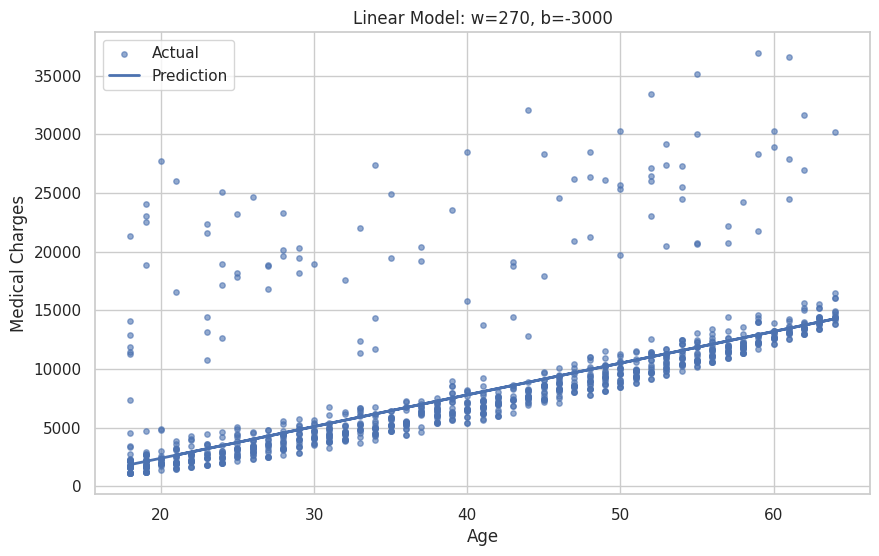

In [31]:
evaluate_parameters(270, -3000)

The previous examples demonstrate why choosing model parameters manually is not practical.

Instead of trying arbitrary values for `w` and `b`, a machine learning algorithm can estimate the parameters from the training data.

This leads us to `LinearRegression` from scikit-learn.

# 4. Simple Linear Regression with Scikit-Learn

We will first predict medical charges using age alone.

This model is intentionally simple so that its behavior can be compared with the manual linear model above.

In [32]:
X = non_smoker_df[["age"]]
y = non_smoker_df["charges"]

model_age = LinearRegression()

model_age.fit(X, y)

LinearRegression()

In [33]:
predictions = model_age.predict(X)

training_rmse = rmse(y, predictions)

print(f"Training RMSE: {training_rmse:.2f}")

Training RMSE: 4662.51


In [34]:
print(f"Coefficient: {model_age.coef_[0]:.2f}")
print(f"Intercept: {model_age.intercept_:.2f}")

Coefficient: 267.25
Intercept: -2091.42


The coefficient represents the estimated change in medical charges associated with a one-unit increase in age, according to this simple linear model.

The intercept represents the model's predicted charge when age is zero. Since age zero is outside the dataset's meaningful range, the intercept should mainly be interpreted as a mathematical component of the regression equation rather than a realistic medical estimate.

# 5. Multiple Linear Regression

A person's medical charges are unlikely to depend on age alone.

We will therefore include:

- Age
- BMI
- Number of children

In [35]:
X = non_smoker_df[["age", "bmi", "children"]]
y = non_smoker_df["charges"]

model_numeric = LinearRegression()

model_numeric.fit(X, y)

predictions = model_numeric.predict(X)

training_rmse = rmse(y, predictions)

print(f"Training RMSE: {training_rmse:.2f}")

Training RMSE: 4608.47


In [36]:
pd.DataFrame({
    "feature": X.columns,
    "coefficient": model_numeric.coef_
})

,feature,coefficient
0,age,265.293844
1,bmi,5.279563
2,children,580.659651


Adding multiple numerical features allows the model to account for more information than age alone.

However, the model still ignores categorical variables such as smoking status and region.

The EDA suggested that smoking status is particularly important, so we need to encode categorical variables before including them in the model.

# 6. Data Preprocessing

Machine learning algorithms require numerical inputs.

The dataset contains categorical variables:

- `sex`
- `smoker`
- `region`

We will encode the binary variables and use one-hot encoding for `region`.

In [37]:
df_model = df.copy()

df_model["smoker"] = df_model["smoker"].map({
    "no": 0,
    "yes": 1
})

df_model["sex"] = df_model["sex"].map({
    "male": 0,
    "female": 1
})

df_model.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


The binary categorical variables are represented numerically:

- `smoker`: `0 = no`, `1 = yes`
- `sex`: `0 = male`, `1 = female`

For `region`, assigning arbitrary numbers such as 0, 1, 2, and 3 would incorrectly imply an ordering.

Instead, we use one-hot encoding.

In [38]:
region_encoded = pd.get_dummies(
    df_model["region"],
    prefix="region",
    dtype=int
)

region_encoded.head()

,region_northeast,region_northwest,region_southeast,region_southwest
0,0,0,0,1
1,0,0,1,0
2,0,0,1,0
3,0,1,0,0
4,0,1,0,0


In [39]:
df_model = pd.concat(
    [df_model.drop(columns="region"), region_encoded],
    axis=1
)

df_model.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0


Each region is now represented by a separate binary feature.

For example:

- `region_northeast`
- `region_northwest`
- `region_southeast`
- `region_southwest`

This allows the linear regression model to estimate separate effects for the different regions.

# 7. Feature Scaling

The numerical features have different ranges:

- Age is measured in years.
- BMI has a different numerical scale.
- Children ranges from 0 to 5.

We will standardize the numerical features using `StandardScaler`.

Standardization transforms a feature approximately according to:

\[
z = \frac{x-\mu}{\sigma}
\]

where:

- `μ` is the feature mean
- `σ` is the feature standard deviation

In [40]:
numeric_features = ["age", "bmi", "children"]

scaler = StandardScaler()

df_model[numeric_features] = scaler.fit_transform(
    df_model[numeric_features]
)

df_model.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.438764,1,-0.453320,-0.908614,1,16884.92400,0,0,0,1
1,-1.509965,0,0.509621,-0.078767,0,1725.55230,0,0,1,0
2,-0.797954,0,0.383307,1.580926,0,4449.46200,0,0,1,0
3,-0.441948,0,-1.305531,-0.908614,0,21984.47061,0,1,0,0
4,-0.513149,0,-0.292556,-0.908614,0,3866.85520,0,1,0,0


After standardization, the numerical features are on a comparable scale.

Scaling is not strictly necessary for ordinary linear regression to work, but it makes coefficient magnitudes easier to compare and is useful when working with many machine learning algorithms.

# 8. Preparing Features and Target

The target is:

`charges`

All remaining relevant columns are used as input features.

In [41]:
X = df_model.drop(columns="charges")
y = df_model["charges"]

print("Features:")
print(X.columns.tolist())

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features:
['age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']

Feature matrix shape: (1338, 9)
Target shape: (1338,)


# 9. Train/Test Split

Evaluating a model on the same data used for training can give an overly optimistic estimate of performance.

To measure how well the model generalizes to unseen data, we split the dataset into:

- **Training set:** used to learn model parameters
- **Test set:** used only for final evaluation

We use 80% of the data for training and 20% for testing.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 1070
Testing samples: 268


The `random_state=42` parameter makes the split reproducible.

This means that running the notebook again produces the same train/test division.

# 10. Training the Final Linear Regression Model

In [43]:
final_model = LinearRegression()

final_model.fit(X_train, y_train)

LinearRegression()

In [44]:
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

## Model Evaluation

We evaluate the model using:

### RMSE

Lower is better.

RMSE measures the typical magnitude of prediction errors in the same units as medical charges.

### R² Score

R² measures the proportion of variance in the target that is explained by the model.

A value closer to 1 indicates that the model explains more of the variation in the target.

In [52]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Testing RMSE:  ${test_rmse:,.2f}")
print(f"Training R²:   {train_r2:.4f}")
print(f"Testing R²:    {test_r2:.4f}")

Training RMSE: $6,105.55
Testing RMSE:  $5,796.28
Training R²:   0.7417
Testing R²:    0.7836


### Interpreting the results

The test-set metrics are the most important numbers because the test data was not used to train the model.

The difference between training and testing performance can also provide an indication of whether the model is generalizing reasonably well.

In [53]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
})

results.head(10)

,Actual,Predicted
764,9095.06825,8969.550274
887,5272.17580,7068.747443
890,29330.98315,36858.410912
1293,9301.89355,9454.678501
259,33750.29180,26973.173457
1312,4536.25900,10864.113164
899,2117.33885,170.280841
752,14210.53595,16903.450287
1286,3732.62510,1092.430936
707,10264.44210,11218.343184


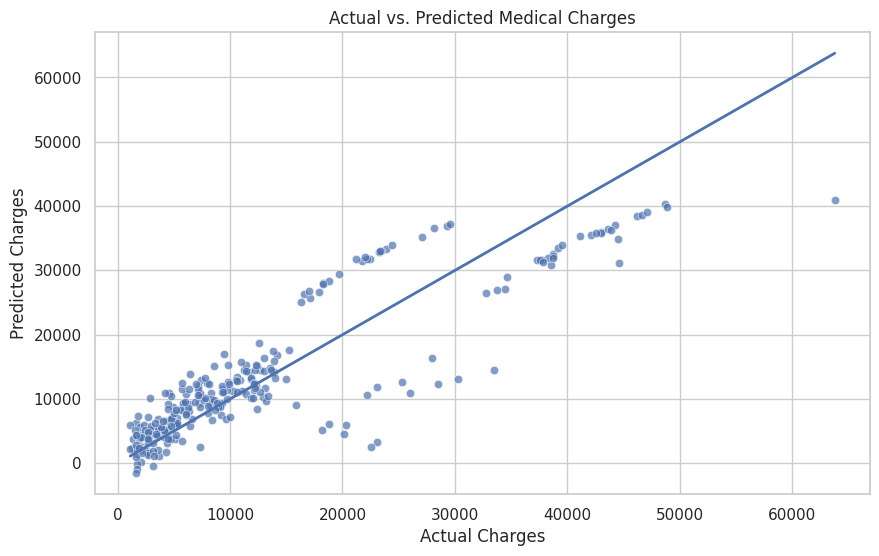

In [54]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.title("Actual vs. Predicted Medical Charges")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()

The diagonal line represents perfect predictions.

Points close to the diagonal indicate predictions close to the actual medical charges.

Large deviations from the diagonal represent larger prediction errors.

# 11. Feature Interpretation

Linear regression assigns a coefficient to each feature.

Because the numerical features were standardized, their coefficients represent the expected change in predicted medical charges associated with a one-standard-deviation increase in that feature, while holding the other features constant.

For binary and one-hot encoded variables, the coefficients represent differences relative to the corresponding reference categories.

In [55]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": final_model.coef_
})

feature_importance["absolute_coefficient"] = (
    feature_importance["coefficient"].abs()
)

feature_importance.sort_values(
    "absolute_coefficient",
    ascending=False
)

,feature,coefficient,absolute_coefficient
4,smoker,23651.128856,23651.128856
0,age,3609.149018,3609.149018
2,bmi,2054.885063,2054.885063
3,children,512.478869,512.478869
5,region_northeast,459.585244,459.585244
8,region_southwest,-350.214110,350.214110
7,region_southeast,-198.279052,198.279052
6,region_northwest,88.907918,88.907918
1,sex,18.591692,18.591692


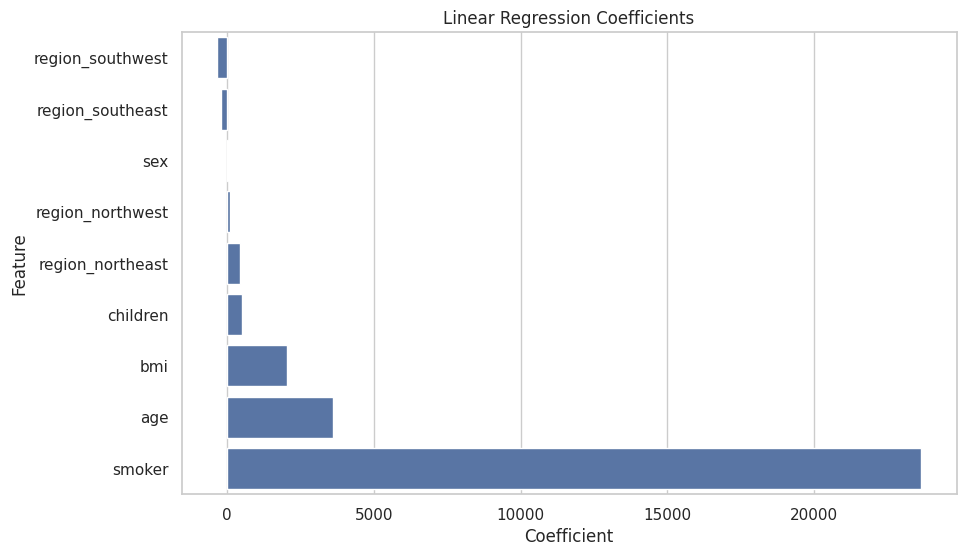

In [56]:
plt.figure(figsize=(10, 6))

plot_data = feature_importance.sort_values(
    "coefficient"
)

sns.barplot(
    data=plot_data,
    x="coefficient",
    y="feature"
)

plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

The coefficient analysis helps identify which variables have the strongest linear associations with predicted medical charges.

The EDA and model coefficients both indicate that smoking status is an especially important feature in this dataset.

However, coefficients should not automatically be interpreted as causal effects. This dataset is observational, and the model describes statistical relationships rather than proving that a particular feature causes higher medical costs.

# 12. Final Results

The final model uses:

- Age
- BMI
- Number of children
- Sex
- Smoking status
- Region

The model is evaluated on a held-out test set using RMSE and R².

This provides a more realistic estimate of how the model performs on previously unseen data than evaluating only on the training data.

In [57]:
final_results = pd.DataFrame({
    "Metric": [
        "Training RMSE",
        "Testing RMSE",
        "Training R²",
        "Testing R²"
    ],
    "Value": [
        train_rmse,
        test_rmse,
        train_r2,
        test_r2
    ]
})

final_results

,Metric,Value
0,Training RMSE,6105.545160
1,Testing RMSE,5796.284659
2,Training R²,0.741726
3,Testing R²,0.783593


# 13. Conclusion

This project demonstrated a complete regression workflow for predicting medical insurance charges.

### Key findings

- Age has a positive relationship with medical charges.
- BMI has some predictive value, although its relationship with charges is less pronounced than smoking status.
- Smoking status is a particularly important predictor in the dataset.
- Categorical variables can be incorporated into linear regression through appropriate encoding.
- Standardization places numerical features on comparable scales.
- Evaluating on a separate test set provides a more realistic estimate of model performance.

### What I learned

The project also provided practical experience with:

- Pandas data manipulation
- Exploratory data analysis
- Data visualization
- Feature encoding
- Feature scaling
- Linear regression
- RMSE
- R²
- Train/test splitting
- Model interpretation

### Limitations

This project uses a relatively simple linear regression model. Medical charges may involve nonlinear relationships and interactions between variables that a basic linear model cannot fully capture.

Possible future improvements include:

- Polynomial features
- Interaction terms
- Ridge and Lasso regression
- Decision trees
- Random forests
- Gradient boosting
- Cross-validation
- Hyperparameter tuning